In [2]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA RTX A2000 Laptop GPU


In [3]:
!pip install nibabel matplotlib numpy scikit-learn tqdm opencv-python

In [4]:
!pip install monai SimpleITK

In [5]:
!pip install pandas

In [6]:
import sys

print(sys.executable)

D:\annacondadeep\envs\torch_env\python.exe


In [7]:
import sys

!{sys.executable} -m pip install pandas

UNET_MODEL

# U-Net Architecture

This figure illustrates the U-Net architecture used for cardiac MRI segmentation.

<img src="unet_architecture.png" width="1200">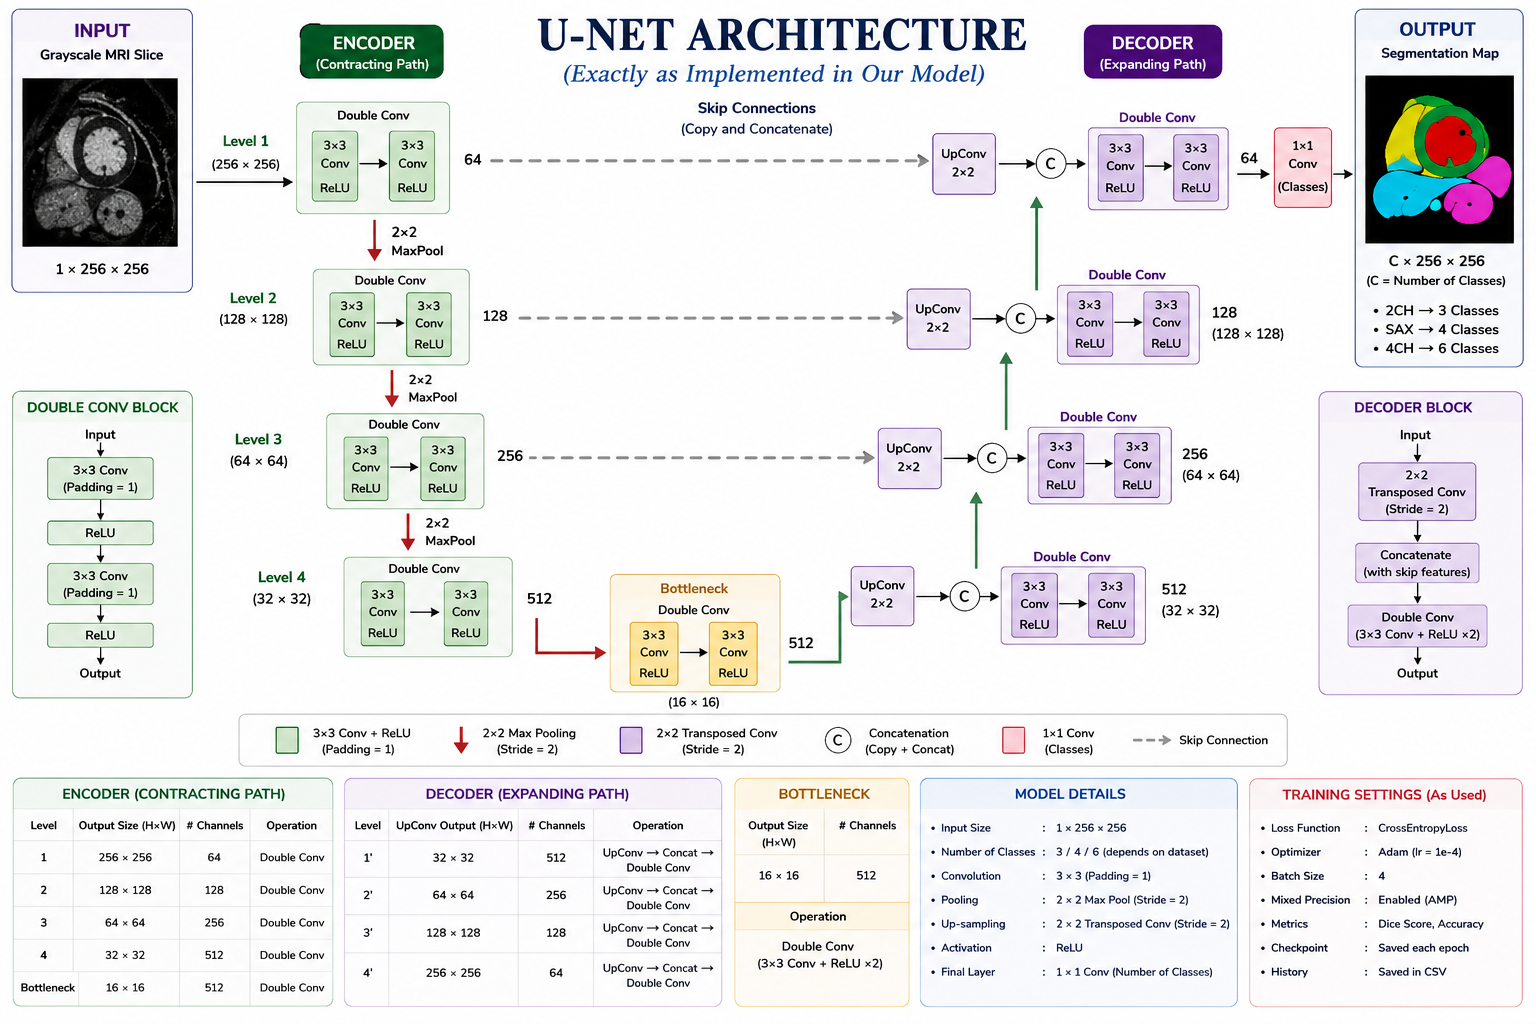

# ============================================
# 🔹 1. UNET_4CH
# ============================================


Total TR Samples : 8285
Train Samples    : 6213
Test Samples     : 2072
Val Samples      : 1200

Device: cuda

🔄 Loading checkpoint...
✅ Resume from epoch 1
📂 Previous history loaded

Epoch 2
---------------------------------------------
Metric       | Train    | Val      | Test    
---------------------------------------------
Loss         | 0.1173 | 0.1288 | 0.0892
Dice         | 0.9547 | 0.9531 | 0.9646
Accuracy     | 0.9547 | 0.9531 |  
💾 Checkpoint Saved

Epoch 3
---------------------------------------------
Metric       | Train    | Val      | Test    
---------------------------------------------
Loss         | 0.0826 | 0.1131 | 0.0739
Dice         | 0.9668 | 0.9584 | 0.9699
Accuracy     | 0.9668 | 0.9584 |  
💾 Checkpoint Saved

Epoch 4
---------------------------------------------
Metric       | Train    | Val      | Test    
---------------------------------------------
Loss         | 0.0704 | 0.1174 | 0.0681
Dice         | 0.9712 | 0.9586 | 0.9722
Accuracy     | 0.9712 | 0.9

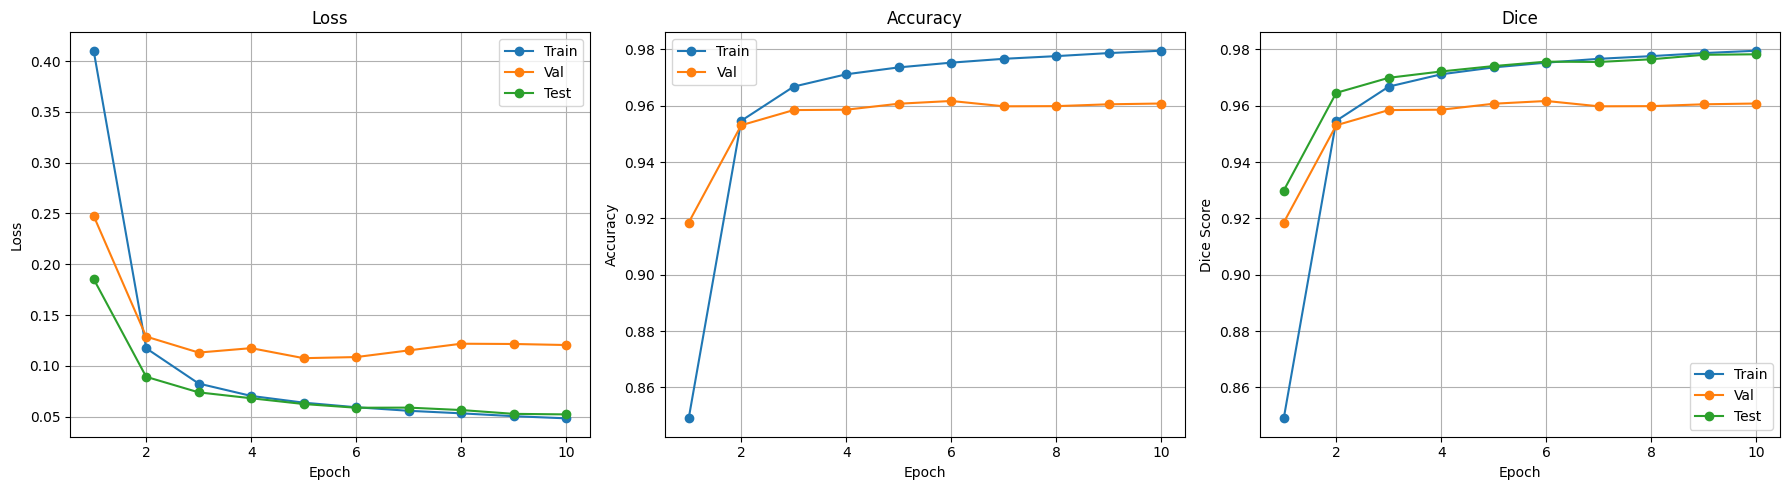

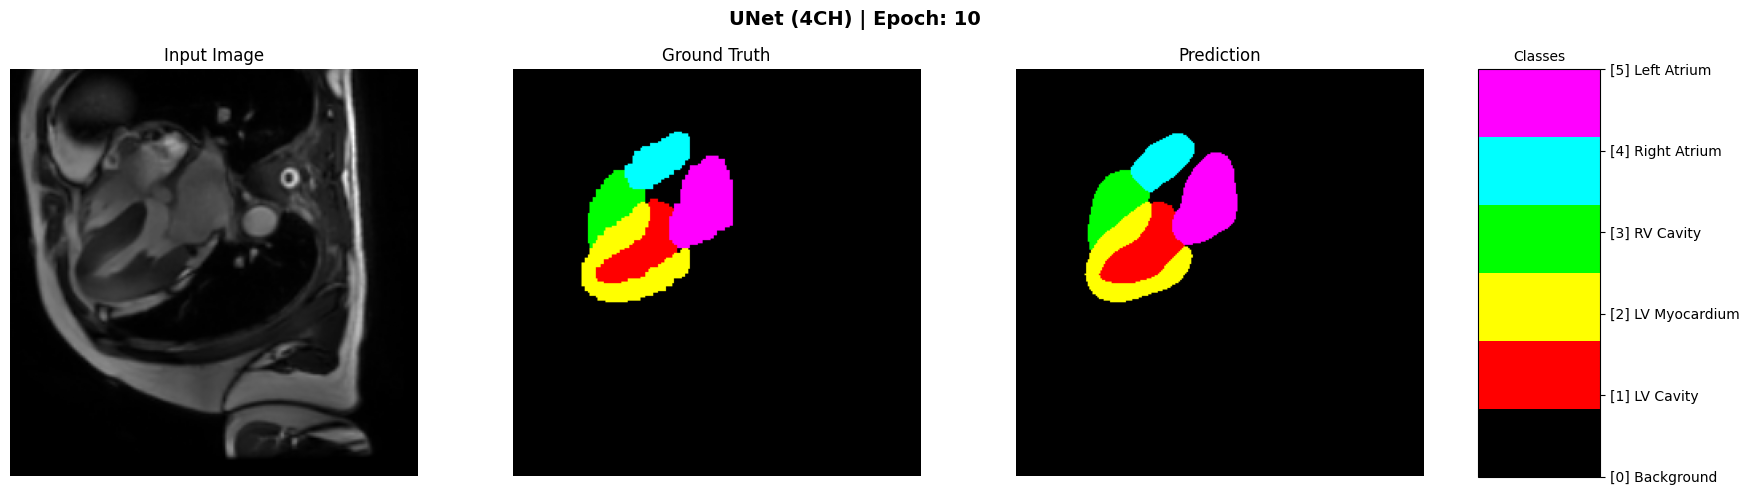

In [10]:
# ============================================
# 🔹 1. ImportsUNET_4CH
# ============================================
#UNET_4CH
import os
import gc
import random
import warnings

import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import nibabel as nib
import pandas as pd

import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import classification_report

# ============================================
# 🔹 Performance Settings
# ============================================

warnings.filterwarnings("ignore")

torch.backends.cudnn.benchmark = True

# ============================================
# 🔹 2. Load Data
# ============================================

BASE_PATH = r"D:\CMR-MULTI\CINE_MULTI"

PROBLEM_TYPE = "CINE"

IMAGE_TYPE = "4CH"

TRAIN_IMAGE_PATH = os.path.join(
    BASE_PATH,
    "4CH_TR",
    "image"
)

TRAIN_MASK_PATH = os.path.join(
    BASE_PATH,
    "4CH_TR",
    "anno"
)

VAL_IMAGE_PATH = os.path.join(
    BASE_PATH,
    "4CH_VAL",
    "image"
)

VAL_MASK_PATH = os.path.join(
    BASE_PATH,
    "4CH_VAL",
    "anno"
)
# ============================================
# 🔹 3. Dataset
# ============================================

class NiftiDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.samples = []

        self.image_dir = image_dir

        self.mask_dir = mask_dir

        files = sorted(os.listdir(image_dir))

        for f in files:

            img_path = os.path.join(image_dir, f)

            img_obj = nib.load(img_path)

            depth = img_obj.shape[2]

            for i in range(depth):

                self.samples.append((f, i))

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        fname, i = self.samples[idx]

        img = nib.load(

            os.path.join(self.image_dir, fname)

        ).dataobj[:, :, i]

        mask = nib.load(

            os.path.join(self.mask_dir, fname)

        ).dataobj[:, :, i]

        img = np.array(img)

        mask = np.array(mask)

        # =====================================
        # Safe Normalization
        # =====================================

        img = img.astype(np.float32)

        if img.max() > img.min():

            img = (img - img.min()) / (

                img.max() - img.min()

            )

        else:

            img = np.zeros_like(img)

        img = np.nan_to_num(img)

        # =====================================
        # Convert to Tensor
        # =====================================

        img = torch.tensor(img).unsqueeze(0).float()

        mask = torch.tensor(mask).long()

        # =====================================
        # Resize Image
        # =====================================

        img = F.interpolate(

            img.unsqueeze(0),

            (256,256),

            mode='bilinear'

        ).squeeze(0)

        # =====================================
        # Resize Mask
        # =====================================

        mask = F.interpolate(

            mask.unsqueeze(0).unsqueeze(0).float(),

            (256,256),

            mode='nearest'

        ).squeeze().long()

        return img, mask

# ============================================
# 🔹 4. Split Dataset
# ============================================

train_test_dataset = NiftiDataset(
    TRAIN_IMAGE_PATH,
    TRAIN_MASK_PATH
)

val_dataset = NiftiDataset(
    VAL_IMAGE_PATH,
    VAL_MASK_PATH
)

total_size = len(train_test_dataset)

train_size = int(0.75 * total_size)

test_size = total_size - train_size

train_data, test_data = random_split(
    train_test_dataset,
    [train_size, test_size]
)

val_data = val_dataset

print(f"\nTotal TR Samples : {total_size}")
print(f"Train Samples    : {train_size}")
print(f"Test Samples     : {test_size}")
print(f"Val Samples      : {len(val_dataset)}")

# ============================================
# 🔹 5. DataLoader
# ============================================

device = torch.device(

    "cuda" if torch.cuda.is_available() else "cpu"

)

PIN_MEMORY = True if device.type == "cuda" else False

train_loader = DataLoader(

    train_data,

    batch_size=4,

    shuffle=True,

    num_workers=0,

    pin_memory=PIN_MEMORY,

    persistent_workers=False

)

val_loader = DataLoader(

    val_data,

    batch_size=4,

    shuffle=False,

    num_workers=0,

    pin_memory=PIN_MEMORY,

    persistent_workers=False

)

test_loader = DataLoader(

    test_data,

    batch_size=4,

    shuffle=False,

    num_workers=0,

    pin_memory=PIN_MEMORY,

    persistent_workers=False

)

# ============================================
# 🔹 6. Model
# ============================================

NUM_CLASSES = 6

class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(in_c, out_c, 3, padding=1),

            nn.ReLU(),

            nn.Conv2d(out_c, out_c, 3, padding=1),

            nn.ReLU()

        )

    def forward(self, x):

        return self.net(x)

class UNet(nn.Module):

    def __init__(self, n_classes):

        super().__init__()

        self.d1 = DoubleConv(1,64)

        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(64,128)

        self.p2 = nn.MaxPool2d(2)

        self.d3 = DoubleConv(128,256)

        self.p3 = nn.MaxPool2d(2)

        self.bn = DoubleConv(256,512)

        self.u3 = nn.ConvTranspose2d(512,256,2,2)

        self.c3 = DoubleConv(512,256)

        self.u2 = nn.ConvTranspose2d(256,128,2,2)

        self.c2 = DoubleConv(256,128)

        self.u1 = nn.ConvTranspose2d(128,64,2,2)

        self.c1 = DoubleConv(128,64)

        self.out = nn.Conv2d(64,n_classes,1)

    def forward(self,x):

        x1 = self.d1(x)

        x2 = self.d2(self.p1(x1))

        x3 = self.d3(self.p2(x2))

        x4 = self.bn(self.p3(x3))

        x = self.c3(

            torch.cat([self.u3(x4),x3],1)

        )

        x = self.c2(

            torch.cat([self.u2(x),x2],1)

        )

        x = self.c1(

            torch.cat([self.u1(x),x1],1)

        )

        return self.out(x)

# ============================================
# 🔹 7. Metrics
# ============================================

def dice(pred, target):

    pred = torch.argmax(pred, dim=1)

    return (pred == target).float().mean()

def acc(pred, target):

    pred = torch.argmax(pred, dim=1)

    return (pred == target).float().mean()

# ============================================
# 🔹 8. Setup
# ============================================

print("\nDevice:", device)

model = UNet(NUM_CLASSES).to(device)

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-4

)

criterion = nn.CrossEntropyLoss()

scaler = torch.amp.GradScaler(

    "cuda",

    enabled=(device.type == "cuda")

)

# ============================================
# 🔹 9. Checkpoint + History
# ============================================

checkpoint_path = r"D:\CMR-MULTI\CINE_MULTI\unet_4CH_checkpoint_v2.pth"

history_path = r"D:\CMR-MULTI\CINE_MULTI\training_history_4CH_v2.csv"

start_epoch = 0

train_loss_l = []
val_loss_l = []
test_loss_l = []

train_dice_l = []
val_dice_l = []
test_dice_l = []

train_acc_l = []
val_acc_l = []


# ============================================
# 🔹 Load Checkpoint
# ============================================

if os.path.exists(checkpoint_path):

    print("\n🔄 Loading checkpoint...")

    checkpoint = torch.load(

        checkpoint_path,

        map_location=device,

        weights_only=False

    )

    try:

        model.load_state_dict(

            checkpoint["model"]

        )

        optimizer.load_state_dict(

            checkpoint["optimizer"]

        )

        start_epoch = checkpoint["epoch"] + 1

        print(f"✅ Resume from epoch {start_epoch}")

    except:

        print("⚠️ Checkpoint incompatible")

        print("🚀 Starting New Training")

else:

    print("\n🚀 New Training")

# ============================================
# 🔹 Load History
# ============================================

if os.path.exists(history_path):

    history_df = pd.read_csv(history_path)

    train_loss_l = history_df["Train Loss"].tolist()
    val_loss_l = history_df["Val Loss"].tolist()
    test_loss_l = history_df["Test Loss"].tolist()

    train_dice_l = history_df["Train Dice"].tolist()
    val_dice_l = history_df["Val Dice"].tolist()
    test_dice_l = history_df["Test Dice"].tolist()

    train_acc_l = history_df["Train Acc"].tolist()
    val_acc_l = history_df["Val Acc"].tolist()
    

    print("📂 Previous history loaded")

else:

    print("🆕 New history created")

# ============================================
# 🔹 10. Training
# ============================================

epochs = 10

for ep in range(start_epoch, epochs):

    # =====================================
    # Train
    # =====================================

    model.train()

    tl, td, ta = 0,0,0

    for x,y in train_loader:

        x = x.to(device)

        y = y.to(device)

        with torch.amp.autocast(

            "cuda",

            enabled=(device.type == "cuda")

        ):

            out = model(x)

            loss = criterion(out,y)

        if torch.isnan(loss):

            print("⚠️ NaN Loss detected")

            continue

        optimizer.zero_grad()

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        tl += loss.item()

        td += dice(out,y).item()

        ta += acc(out,y).item()

        del out
        del loss

    tl /= len(train_loader)

    td /= len(train_loader)

    ta /= len(train_loader)

    # =====================================
    # Validation
    # =====================================

    model.eval()

    vl, vd, va = 0,0,0

    with torch.no_grad():

        for x,y in val_loader:

            x = x.to(device)

            y = y.to(device)

            out = model(x)

            loss = criterion(out,y)

            vl += loss.item()

            vd += dice(out,y).item()

            va += acc(out,y).item()

            del out
            del loss

    vl /= len(val_loader)

    vd /= len(val_loader)

    va /= len(val_loader)

    # =====================================
    # Test
    # =====================================

    tloss, tdice = 0,0

    with torch.no_grad():

        for x,y in test_loader:

            x = x.to(device)

            y = y.to(device)

            out = model(x)

            loss = criterion(out,y)

            tloss += loss.item()

            tdice += dice(out,y).item()

            

            del out
            del loss

    tloss /= len(test_loader)

    tdice /= len(test_loader)

   

    # =====================================
    # Save Metrics
    # =====================================

    train_loss_l.append(tl)

    val_loss_l.append(vl)

    test_loss_l.append(tloss)

    train_dice_l.append(td)

    val_dice_l.append(vd)

    test_dice_l.append(tdice)

    train_acc_l.append(ta)

    val_acc_l.append(va)

    

    # =====================================
    # Save History CSV
    # =====================================

    history_df = pd.DataFrame({

        "Epoch": range(1, len(train_loss_l)+1),

        "Train Loss": train_loss_l,
        "Val Loss": val_loss_l,
        "Test Loss": test_loss_l,

        "Train Dice": train_dice_l,
        "Val Dice": val_dice_l,
        "Test Dice": test_dice_l,

        "Train Acc": train_acc_l,
        "Val Acc": val_acc_l,
      

    })

    history_df.to_csv(

        history_path,

        index=False

    )

    # =====================================
    # Print Results
    # =====================================

    print(f"\nEpoch {ep+1}")

    print("-"*45)

    print(f"{'Metric':<12} | {'Train':<8} | {'Val':<8} | {'Test':<8}")

    print("-"*45)

    print(f"{'Loss':<12} | {tl:.4f} | {vl:.4f} | {tloss:.4f}")

    print(f"{'Dice':<12} | {td:.4f} | {vd:.4f} | {tdice:.4f}")

    print(f"{'Accuracy':<12} | {ta:.4f} | {va:.4f} | {' '}")
    # =====================================
    # Save Checkpoint
    # =====================================

    torch.save({

        "epoch": ep,

        "model": model.state_dict(),

        "optimizer": optimizer.state_dict()

    }, checkpoint_path)

    print("💾 Checkpoint Saved")

    gc.collect()

    torch.cuda.empty_cache()

# ============================================
# 🔹 11. Lightweight Classification Report
# ============================================

all_preds = []

all_targets = []

model.eval()

MAX_BATCHES = 20

with torch.no_grad():

    for i, (x,y) in enumerate(test_loader):

        if i >= MAX_BATCHES:
            break

        x = x.to(device)

        out = model(x)

        preds = torch.argmax(out, dim=1)

        all_preds.extend(
            preds.cpu().view(-1).numpy()[::50]
        )

        all_targets.extend(
            y.view(-1).numpy()[::50]
        )

print("\n📊 Classification Report:\n")

print(

    classification_report(

        all_targets,

        all_preds,

        digits=2,

        target_names=[

            "Background",

            "LV Cavity",

            "LV Myocardium",

            "RV Cavity",

            "Right Atrium",

            "Left Atrium"

        ]

    )

)

# ============================================
# 🔹 12. Plot Results
# ============================================

ep_range = range(

    1,

    len(train_loss_l)+1

)

plt.figure(figsize=(18,5))

# Loss
plt.subplot(1,3,1)

plt.plot(ep_range, train_loss_l, 'o-', label='Train')
plt.plot(ep_range, val_loss_l, 'o-', label='Val')
plt.plot(ep_range, test_loss_l, 'o-', label='Test')

plt.title("Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

# Accuracy
plt.subplot(1,3,2)

plt.plot(ep_range, train_acc_l, 'o-', label='Train')
plt.plot(ep_range, val_acc_l, 'o-', label='Val')


plt.title("Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

# Dice
plt.subplot(1,3,3)

plt.plot(ep_range, train_dice_l, 'o-', label='Train')
plt.plot(ep_range, val_dice_l, 'o-', label='Val')
plt.plot(ep_range, test_dice_l, 'o-', label='Test')

plt.title("Dice")

plt.xlabel("Epoch")

plt.ylabel("Dice Score")

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

# ============================================
# 🔹 13. Visualization
# ============================================

MODEL_NAME = "UNet (4CH)"

CLASS_NAMES = [

    "[0] Background",

    "[1] LV Cavity",

    "[2] LV Myocardium",

    "[3] RV Cavity",

    "[4] Right Atrium",

    "[5] Left Atrium"

]

COLORS = [

    (0, 0, 0),        # Background

    (1, 0, 0),        # LV Cavity

    (1, 1, 0),        # LV Myocardium

    (0, 1, 0),        # RV Cavity

    (0, 1, 1),        # Right Atrium

    (1, 0, 1)         # Left Atrium

]

CMAP = ListedColormap(COLORS)

checkpoint = torch.load(

    checkpoint_path,

    map_location=device,

    weights_only=False

)

epoch_num = checkpoint["epoch"] + 1

model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

    preds = torch.argmax(outputs, dim=1)

images = images.cpu()

masks = masks.cpu()

preds = preds.cpu()

idx = random.randint(

    0,

    images.shape[0] - 1

)

img = images[idx].squeeze().numpy()

gt = masks[idx].numpy()

pr = preds[idx].numpy()

fig, axes = plt.subplots(

    1,

    4,

    figsize=(18,5),

    gridspec_kw={

        'width_ratios': [1,1,1,0.25]

    }

)

# Input
axes[0].imshow(

    img,

    cmap='gray'

)

axes[0].set_title("Input Image")

axes[0].axis('off')

# GT
axes[1].imshow(

    gt,

    cmap=CMAP,

    vmin=0,

    vmax=5

)

axes[1].set_title("Ground Truth")

axes[1].axis('off')

# Prediction
axes[2].imshow(

    pr,

    cmap=CMAP,

    vmin=0,

    vmax=5

)

axes[2].set_title("Prediction")

axes[2].axis('off')

# Colorbar
norm = plt.Normalize(

    vmin=0,

    vmax=5

)

cbar = plt.colorbar(

    plt.cm.ScalarMappable(

        norm=norm,

        cmap=CMAP

    ),

    cax=axes[3]

)

cbar.set_ticks(

    np.arange(len(CLASS_NAMES))

)

cbar.set_ticklabels(CLASS_NAMES)

cbar.ax.set_title(

    "Classes",

    fontsize=10

)

# Main Title
plt.suptitle(

    f"{MODEL_NAME} | Epoch: {epoch_num}",

    fontsize=14,

    fontweight='bold'

)

plt.tight_layout()

plt.show()

In [11]:
# ============================================
# Final Test Accuracy
# ============================================

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        outputs = model(x)

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y).sum().item()

        total += y.numel()

test_accuracy = correct / total

print(f"\nFinal Test Accuracy = {test_accuracy:.4f}")



Final Test Accuracy = 0.9783


# 🎨 Professional Medical Visualization
# 4CH / 6 Classes

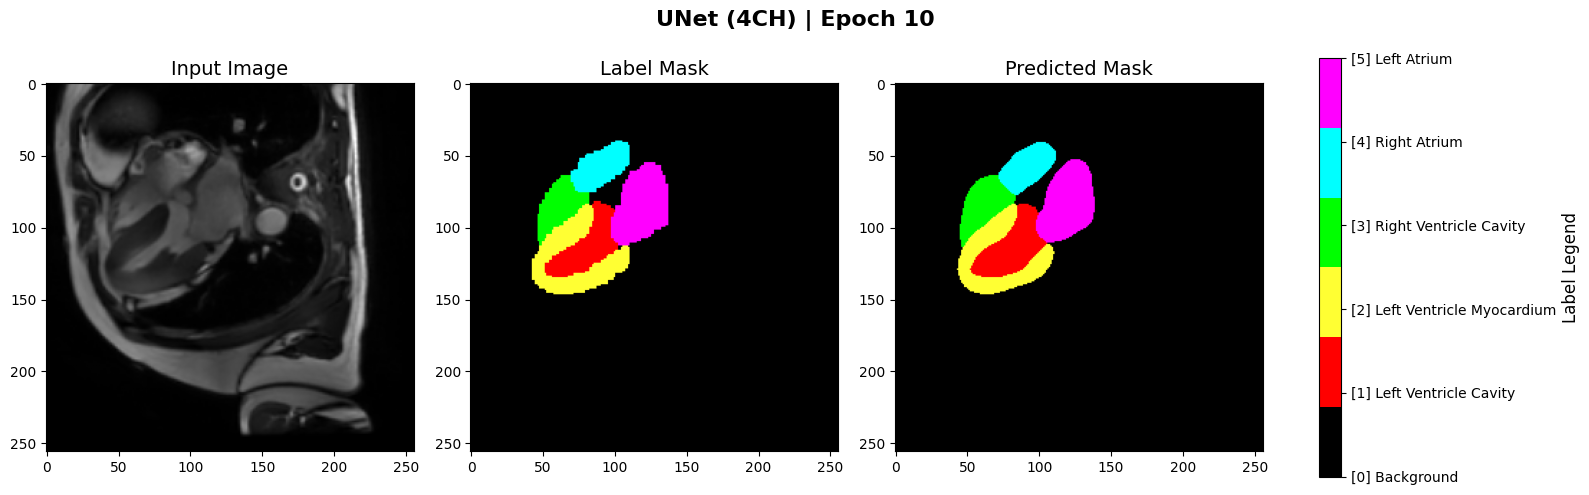

In [12]:
# ============================================
# 🎨 Professional Medical Visualization
# 4CH / 6 Classes
# ============================================

import random
import torch
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

# ============================================
# 📌 Model Name
# ============================================

MODEL_NAME = "UNet (4CH)"

# ============================================
# 📌 Load Checkpoint Info
# ============================================

checkpoint = torch.load(

    checkpoint_path,

    map_location=device,

    weights_only=False

)

epoch_num = checkpoint["epoch"] + 1

# ============================================
# 📌 Class Labels
# ============================================

CLASS_NAMES = [

    "[0] Background",

    "[1] Left Ventricle Cavity",

    "[2] Left Ventricle Myocardium",

    "[3] Right Ventricle Cavity",

    "[4] Right Atrium",

    "[5] Left Atrium"

]

# ============================================
# 🎨 Colors
# ============================================

COLORS = [

    (0, 0, 0),        # Background → Black

    (1, 0, 0),        # LV Cavity → Red

    (1, 1, 0.2),      # LV Myocardium → Yellow

    (0, 1, 0),        # RV Cavity → Green

    (0, 1, 1),        # Right Atrium → Cyan

    (1, 0, 1)         # Left Atrium → Magenta

]

CMAP = ListedColormap(COLORS)

# ============================================
# 🧠 Prediction
# ============================================

model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

    preds = torch.argmax(outputs, dim=1)

images = images.cpu()

masks = masks.cpu()

preds = preds.cpu()

# ============================================
# 🎲 Random Sample
# ============================================

idx = random.randint(
    0,
    images.shape[0] - 1
)

img = images[idx].squeeze().numpy()

gt = masks[idx].numpy()

pr = preds[idx].numpy()

# ============================================
# 📊 Plot Figure
# ============================================

fig, axes = plt.subplots(

    1,
    4,

    figsize=(16,5),

    gridspec_kw={
        'width_ratios': [1,1,1,0.06]
    }

)

# ============================================
# 🖼️ Input Image
# ============================================

axes[0].imshow(
    img,
    cmap='gray'
)

axes[0].set_title(
    "Input Image",
    fontsize=14
)

axes[0].axis('on')

# ============================================
# 🎯 Ground Truth
# ============================================

axes[1].imshow(

    gt,

    cmap=CMAP,

    vmin=0,

    vmax=5

)

axes[1].set_title(

    "Label Mask",

    fontsize=14

)

axes[1].axis('on')

# ============================================
# 🤖 Prediction
# ============================================

axes[2].imshow(

    pr,

    cmap=CMAP,

    vmin=0,

    vmax=5

)

axes[2].set_title(

    "Predicted Mask",

    fontsize=14

)

axes[2].axis('on')

# ============================================
# 🎨 Colorbar
# ============================================

norm = plt.Normalize(
    vmin=0,
    vmax=5
)

cbar = plt.colorbar(

    plt.cm.ScalarMappable(

        norm=norm,

        cmap=CMAP

    ),

    cax=axes[3]

)

cbar.set_ticks(
    np.arange(len(CLASS_NAMES))
)

cbar.set_ticklabels(CLASS_NAMES)

cbar.ax.set_ylabel(

    "Label Legend",

    rotation=90,

    fontsize=12

)

# ============================================
# 🏷️ Main Title
# ============================================

plt.suptitle(

    f"{MODEL_NAME} | Epoch {epoch_num}",

    fontsize=16,

    fontweight='bold'

)

plt.tight_layout()

plt.show()

# ============================================
# 🔹 2. UNET_SAX
# ============================================


Total TR Samples : 29605
Train Samples    : 22203
Test Samples     : 7402
Val Samples      : 4550

Device: cuda

🚀 New Training
🆕 New history created

Epoch 1
---------------------------------------------
Metric       | Train    | Val      | Test    
---------------------------------------------
Loss         | 0.1368 | 0.0884 | 0.0599
Dice         | 0.9504 | 0.9662 | 0.9767
Accuracy     | 0.9504 | 0.9662 |  
💾 Checkpoint Saved
📁 History Saved

Epoch 2
---------------------------------------------
Metric       | Train    | Val      | Test    
---------------------------------------------
Loss         | 0.0508 | 0.0773 | 0.0419
Dice         | 0.9800 | 0.9718 | 0.9832
Accuracy     | 0.9800 | 0.9718 |  
💾 Checkpoint Saved
📁 History Saved

Epoch 3
---------------------------------------------
Metric       | Train    | Val      | Test    
---------------------------------------------
Loss         | 0.0380 | 0.0743 | 0.0346
Dice         | 0.9846 | 0.9732 | 0.9860
Accuracy     | 0.9846 | 0.97

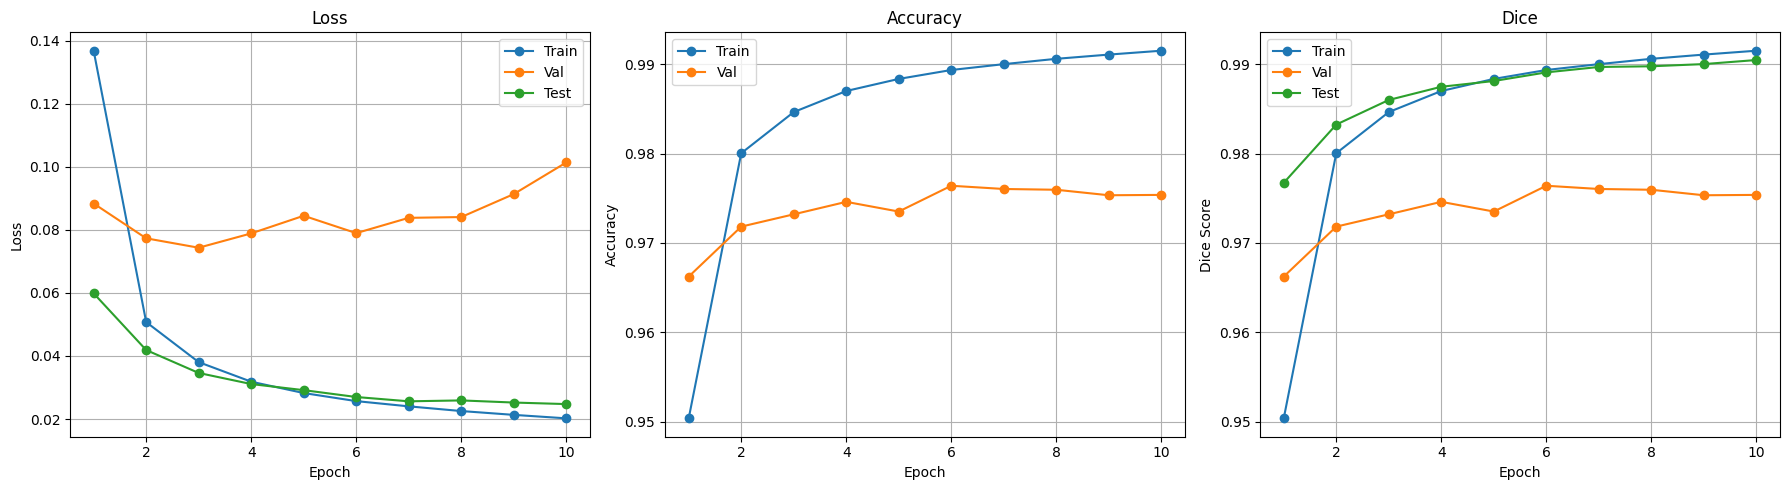

In [17]:
# ============================================
# 🔹 1. Imports
# ============================================

import os
import gc
import warnings

import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import nibabel as nib
import pandas as pd

import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report

# ============================================
# 🔹 Performance Settings
# ============================================

warnings.filterwarnings("ignore")

torch.backends.cudnn.benchmark = True

# ============================================
# 🔹 2. Load Data
# ============================================

BASE_PATH = r"D:\CMR-MULTI\CINE_MULTI"

PROBLEM_TYPE = "CINE"

IMAGE_TYPE = "SAX"

TRAIN_IMAGE_PATH = os.path.join(
    BASE_PATH,
    "SAX_TR",
    "image"
)

TRAIN_MASK_PATH = os.path.join(
    BASE_PATH,
    "SAX_TR",
    "anno"
)

VAL_IMAGE_PATH = os.path.join(
    BASE_PATH,
    "SAX_VAL",
    "image"
)

VAL_MASK_PATH = os.path.join(
    BASE_PATH,
    "SAX_VAL",
    "anno"
)

# ============================================
# 🔹 3. Dataset
# ============================================

class NiftiDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.samples = []

        self.image_dir = image_dir

        self.mask_dir = mask_dir

        files = sorted(os.listdir(image_dir))

        # Memory-safe metadata loading
        for f in files:

            img_path = os.path.join(image_dir, f)

            img_obj = nib.load(img_path)

            depth = img_obj.shape[2]

            for i in range(depth):

                self.samples.append((f, i))

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        fname, i = self.samples[idx]

        # Load one slice only
        img = nib.load(

            os.path.join(self.image_dir, fname)

        ).dataobj[:, :, i]

        mask = nib.load(

            os.path.join(self.mask_dir, fname)

        ).dataobj[:, :, i]

        img = np.array(img)

        mask = np.array(mask)

        # =====================================
        # Safe Normalization
        # =====================================

        img = img.astype(np.float32)

        if img.max() > img.min():

            img = (img - img.min()) / (

                img.max() - img.min()

            )

        else:

            img = np.zeros_like(img)

        # Remove NaN
        img = np.nan_to_num(img)

        # =====================================
        # Convert to Tensor
        # =====================================

        img = torch.tensor(img).unsqueeze(0).float()

        mask = torch.tensor(mask).long()

        # =====================================
        # Resize Image
        # =====================================

        img = F.interpolate(

            img.unsqueeze(0),

            (256,256),

            mode='bilinear'

        ).squeeze(0)

        # =====================================
        # Resize Mask
        # =====================================

        mask = F.interpolate(

            mask.unsqueeze(0).unsqueeze(0).float(),

            (256,256),

            mode='nearest'

        ).squeeze().long()

        return img, mask

# ============================================
# 🔹 4. Split Dataset
# ============================================

train_test_dataset = NiftiDataset(
    TRAIN_IMAGE_PATH,
    TRAIN_MASK_PATH
)

val_dataset = NiftiDataset(
    VAL_IMAGE_PATH,
    VAL_MASK_PATH
)

total_size = len(train_test_dataset)

train_size = int(0.75 * total_size)

test_size = total_size - train_size

train_data, test_data = random_split(
    train_test_dataset,
    [train_size, test_size]
)

val_data = val_dataset

print(f"\nTotal TR Samples : {total_size}")
print(f"Train Samples    : {train_size}")
print(f"Test Samples     : {test_size}")
print(f"Val Samples      : {len(val_dataset)}")

# ============================================
# 🔹 5. DataLoader
# ============================================

device = torch.device(

    "cuda" if torch.cuda.is_available() else "cpu"

)

PIN_MEMORY = True if device.type == "cuda" else False

train_loader = DataLoader(

    train_data,

    batch_size=4,

    shuffle=True,

    num_workers=0,

    pin_memory=PIN_MEMORY,

    persistent_workers=False

)

val_loader = DataLoader(

    val_data,

    batch_size=4,

    shuffle=False,

    num_workers=0,

    pin_memory=PIN_MEMORY,

    persistent_workers=False

)

test_loader = DataLoader(

    test_data,

    batch_size=4,

    shuffle=False,

    num_workers=0,

    pin_memory=PIN_MEMORY,

    persistent_workers=False

)

# ============================================
# 🔹 6. Model
# ============================================

NUM_CLASSES = 4

class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(in_c, out_c, 3, padding=1),

            nn.ReLU(),

            nn.Conv2d(out_c, out_c, 3, padding=1),

            nn.ReLU()

        )

    def forward(self, x):

        return self.net(x)

class UNet(nn.Module):

    def __init__(self, n_classes):

        super().__init__()

        self.d1 = DoubleConv(1,64)

        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(64,128)

        self.p2 = nn.MaxPool2d(2)

        self.d3 = DoubleConv(128,256)

        self.p3 = nn.MaxPool2d(2)

        self.bn = DoubleConv(256,512)

        self.u3 = nn.ConvTranspose2d(512,256,2,2)

        self.c3 = DoubleConv(512,256)

        self.u2 = nn.ConvTranspose2d(256,128,2,2)

        self.c2 = DoubleConv(256,128)

        self.u1 = nn.ConvTranspose2d(128,64,2,2)

        self.c1 = DoubleConv(128,64)

        self.out = nn.Conv2d(64,n_classes,1)

    def forward(self,x):

        x1 = self.d1(x)

        x2 = self.d2(self.p1(x1))

        x3 = self.d3(self.p2(x2))

        x4 = self.bn(self.p3(x3))

        x = self.c3(

            torch.cat([self.u3(x4),x3],1)

        )

        x = self.c2(

            torch.cat([self.u2(x),x2],1)

        )

        x = self.c1(

            torch.cat([self.u1(x),x1],1)

        )

        return self.out(x)

# ============================================
# 🔹 7. Metrics
# ============================================

def dice(pred, target):

    pred = torch.argmax(pred, dim=1)

    return (pred == target).float().mean()

def acc(pred, target):

    pred = torch.argmax(pred, dim=1)

    return (pred == target).float().mean()

# ============================================
# 🔹 8. Setup
# ============================================

print("\nDevice:", device)

model = UNet(NUM_CLASSES).to(device)

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-4

)

criterion = nn.CrossEntropyLoss()

# Mixed Precision
scaler = torch.amp.GradScaler(

    "cuda",

    enabled=(device.type == "cuda")

)

# ============================================
# 🔹 9. Checkpoint
# ============================================

checkpoint_path = r"D:\CMR-MULTI\CINE_MULTI\unet_SAX_checkpoint_v22.pth"
# ============================================
# 🔹 9. Checkpoint + History
# ============================================



start_epoch = 0

train_loss_l = []
val_loss_l = []
test_loss_l = []

train_dice_l = []
val_dice_l = []
test_dice_l = []

train_acc_l = []
val_acc_l = []

start_epoch = 0

if os.path.exists(checkpoint_path):

    print("\n🔄 Loading checkpoint...")

    checkpoint = torch.load(

        checkpoint_path,

        map_location=device,

        weights_only=False

    )

    try:

        model.load_state_dict(

            checkpoint["model"]

        )

        optimizer.load_state_dict(

            checkpoint["optimizer"]

        )

        start_epoch = checkpoint["epoch"] + 1

        print(f"✅ Resume from epoch {start_epoch}")

    except:

        print("⚠️ Checkpoint incompatible")

        print("🚀 Starting New Training")

else:

    print("\n🚀 New Training")

# ============================================
# 🔹 10. History File
# ============================================

history_path = r"D:\CMR-MULTI\CINE_MULTI\training_history_1.csv"

if os.path.exists(history_path):

    history_df = pd.read_csv(history_path)

    train_loss_l = history_df["Train Loss"].tolist()

    val_loss_l = history_df["Val Loss"].tolist()

    test_loss_l = history_df["Test Loss"].tolist()

    train_dice_l = history_df["Train Dice"].tolist()

    val_dice_l = history_df["Val Dice"].tolist()

    test_dice_l = history_df["Test Dice"].tolist()

    train_acc_l = history_df["Train Acc"].tolist()

    val_acc_l = history_df["Val Acc"].tolist()

  

    print("✅ Previous history loaded")

else:

    train_loss_l = []
    val_loss_l = []
    test_loss_l = []

    train_dice_l = []
    val_dice_l = []
    test_dice_l = []

    train_acc_l = []
    val_acc_l = []
    

    print("🆕 New history created")

# ============================================
# 🔹 11. Training
# ============================================

epochs = 10

for ep in range(start_epoch, epochs):

    # =====================================
    # Train
    # =====================================

    model.train()

    tl, td, ta = 0,0,0

    for x,y in train_loader:

        x = x.to(device)

        y = y.to(device)

        with torch.amp.autocast(

            "cuda",

            enabled=(device.type == "cuda")

        ):

            out = model(x)

            loss = criterion(out,y)

        # Skip NaN
        if torch.isnan(loss):

            print("⚠️ NaN Loss detected")

            continue

        optimizer.zero_grad()

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        tl += loss.item()

        td += dice(out,y).item()

        ta += acc(out,y).item()

        # Free GPU Memory
        del out
        del loss

    tl /= len(train_loader)

    td /= len(train_loader)

    ta /= len(train_loader)

    # =====================================
    # Validation
    # =====================================

    model.eval()

    vl, vd, va = 0,0,0

    with torch.no_grad():

        for x,y in val_loader:

            x = x.to(device)

            y = y.to(device)

            out = model(x)

            loss = criterion(out,y)

            vl += loss.item()

            vd += dice(out,y).item()

            va += acc(out,y).item()

            del out
            del loss

    vl /= len(val_loader)

    vd /= len(val_loader)

    va /= len(val_loader)

    # =====================================
    # Test
    # =====================================

    tloss, tdice = 0,0

    with torch.no_grad():

        for x,y in test_loader:

            x = x.to(device)

            y = y.to(device)

            out = model(x)

            loss = criterion(out,y)

            tloss += loss.item()

            tdice += dice(out,y).item()

           

            del out
            del loss

    tloss /= len(test_loader)

    tdice /= len(test_loader)

 

    # =====================================
    # Save Metrics
    # =====================================

    train_loss_l.append(tl)

    val_loss_l.append(vl)

    test_loss_l.append(tloss)

    train_dice_l.append(td)

    val_dice_l.append(vd)

    test_dice_l.append(tdice)

    train_acc_l.append(ta)

    val_acc_l.append(va)

    

    # =====================================
    # Print Results
    # =====================================

    print(f"\nEpoch {ep+1}")

    print("-"*45)

    print(f"{'Metric':<12} | {'Train':<8} | {'Val':<8} | {'Test':<8}")

    print("-"*45)

    print(f"{'Loss':<12} | {tl:.4f} | {vl:.4f} | {tloss:.4f}")

    print(f"{'Dice':<12} | {td:.4f} | {vd:.4f} | {tdice:.4f}")


    print(f"{'Accuracy':<12} | {ta:.4f} | {va:.4f} | {' '}")

    # =====================================
    # Save Checkpoint
    # =====================================

    torch.save({

        "epoch": ep,

        "model": model.state_dict(),

        "optimizer": optimizer.state_dict()

    }, checkpoint_path)

    print("💾 Checkpoint Saved")

    # =====================================
    # Save History CSV
    # =====================================

    history_df = pd.DataFrame({

        "Epoch": list(

            range(1, len(train_loss_l)+1)

        ),

        "Train Loss": train_loss_l,

        "Val Loss": val_loss_l,

        "Test Loss": test_loss_l,

        "Train Dice": train_dice_l,

        "Val Dice": val_dice_l,

        "Test Dice": test_dice_l,

        "Train Acc": train_acc_l,

        "Val Acc": val_acc_l,


    })

    history_df.to_csv(

        history_path,

        index=False

    )

    print("📁 History Saved")

    # =====================================
    # Clear Memory
    # =====================================

    gc.collect()

    torch.cuda.empty_cache()

# ============================================
# 🔹 12. Lightweight Classification Report
# ============================================

from sklearn.metrics import classification_report

all_preds = []

all_targets = []

model.eval()

MAX_BATCHES = 20

with torch.no_grad():

    for i, (x,y) in enumerate(test_loader):

        if i >= MAX_BATCHES:
            break

        x = x.to(device)

        out = model(x)

        preds = torch.argmax(out, dim=1)

        # Take smaller sample only
        all_preds.extend(
            preds.cpu().view(-1).numpy()[::50]
        )

        all_targets.extend(
            y.view(-1).numpy()[::50]
        )

print("\n📊 Classification Report:\n")

print(

    classification_report(

        all_targets,

        all_preds,

        digits=2

    )

)
# ============================================
# 🔹 13. Plot Results
# ============================================

ep_range = range(

    1,

    len(train_loss_l)+1

)

plt.figure(figsize=(18,5))

# ============================================
# Loss Plot
# ============================================

plt.subplot(1,3,1)

plt.plot(

    ep_range,

    train_loss_l,

    'o-',

    label='Train'

)

plt.plot(

    ep_range,

    val_loss_l,

    'o-',

    label='Val'

)

plt.plot(

    ep_range,

    test_loss_l,

    'o-',

    label='Test'

)

plt.title("Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

# ============================================
# Accuracy Plot
# ============================================

plt.subplot(1,3,2)

plt.plot(

    ep_range,

    train_acc_l,

    'o-',

    label='Train'

)

plt.plot(

    ep_range,

    val_acc_l,

    'o-',

    label='Val'

)


plt.title("Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

# ============================================
# Dice Plot
# ============================================

plt.subplot(1,3,3)

plt.plot(

    ep_range,

    train_dice_l,

    'o-',

    label='Train'

)

plt.plot(

    ep_range,

    val_dice_l,

    'o-',

    label='Val'

)

plt.plot(

    ep_range,

    test_dice_l,

    'o-',

    label='Test'

)

plt.title("Dice")

plt.xlabel("Epoch")

plt.ylabel("Dice Score")

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

In [18]:
# ============================================
# Final Test Accuracy
# ============================================

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        outputs = model(x)

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y).sum().item()

        total += y.numel()

test_accuracy = correct / total

print(f"\nFinal Test Accuracy = {test_accuracy:.4f}")



Final Test Accuracy = 0.9905


# 🎨 Professional Medical Visualization
# SAX / 4 Classes

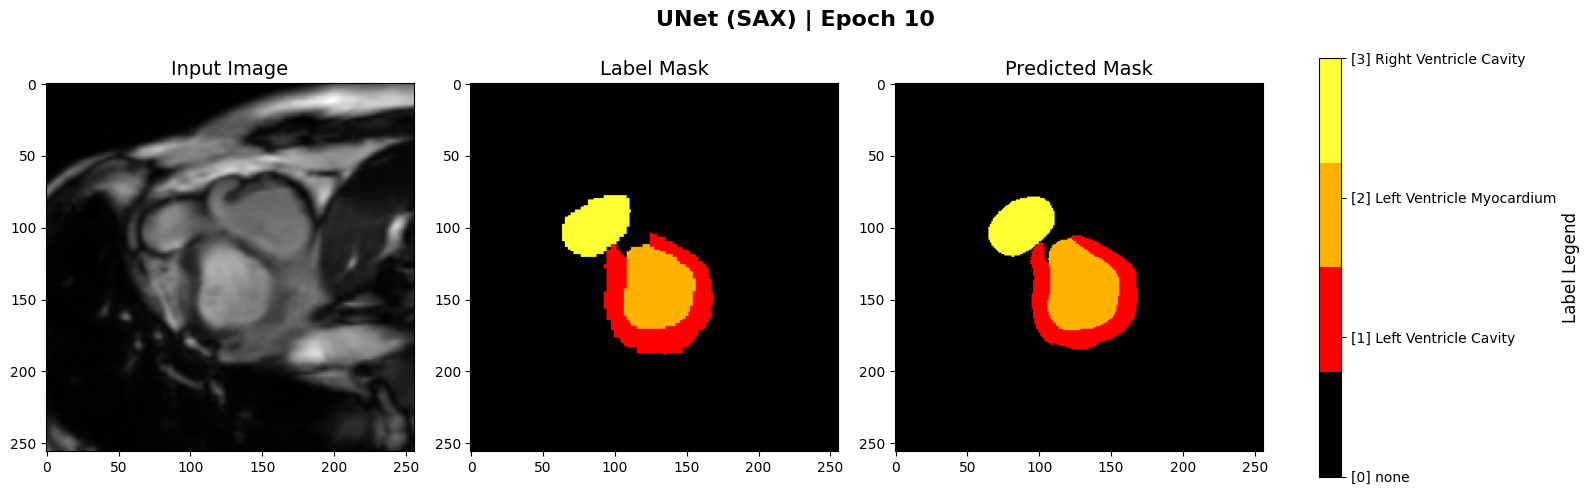

In [19]:
# ============================================
# 🎨 Professional Medical Visualization
# SAX / 4 Classes
# ============================================

import random
import torch
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

# ============================================
# 📌 Model Name
# ============================================

MODEL_NAME = "UNet (SAX)"

# ============================================
# 📌 Load Checkpoint Info
# ============================================

checkpoint = torch.load(

    checkpoint_path,

    map_location=device,

    weights_only=False

)

epoch_num = checkpoint["epoch"] + 1

# ============================================
# 📌 Class Labels
# ============================================

CLASS_NAMES = [

    "[0] none",

    "[1] Left Ventricle Cavity",

    "[2] Left Ventricle Myocardium",

    "[3] Right Ventricle Cavity"

]

# ============================================
# 🎨 Colors
# ============================================

COLORS = [

    (0, 0, 0),        # Background → Black

    (1, 0, 0),        # LV Cavity → Red

    (1, 0.7, 0),      # LV Myocardium → Orange

    (1, 1, 0.2)       # RV Cavity → Yellow

]

CMAP = ListedColormap(COLORS)

# ============================================
# 🧠 Prediction
# ============================================

model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

    preds = torch.argmax(outputs, dim=1)

images = images.cpu()

masks = masks.cpu()

preds = preds.cpu()

# ============================================
# 🎲 Random Sample
# ============================================

idx = random.randint(
    0,
    images.shape[0] - 1
)

img = images[idx].squeeze().numpy()

gt = masks[idx].numpy()

pr = preds[idx].numpy()

# ============================================
# 📊 Plot Figure
# ============================================

fig, axes = plt.subplots(

    1,
    4,

    figsize=(16,5),

    gridspec_kw={
        'width_ratios': [1,1,1,0.06]
    }

)

# ============================================
# 🖼️ Input Image
# ============================================

axes[0].imshow(
    img,
    cmap='gray'
)

axes[0].set_title(
    "Input Image",
    fontsize=14
)

axes[0].axis('on')

# ============================================
# 🎯 Ground Truth
# ============================================

axes[1].imshow(

    gt,

    cmap=CMAP,

    vmin=0,

    vmax=3

)

axes[1].set_title(

    "Label Mask",

    fontsize=14

)

axes[1].axis('on')

# ============================================
# 🤖 Prediction
# ============================================

axes[2].imshow(

    pr,

    cmap=CMAP,

    vmin=0,

    vmax=3

)

axes[2].set_title(

    "Predicted Mask",

    fontsize=14

)

axes[2].axis('on')

# ============================================
# 🎨 Colorbar
# ============================================

norm = plt.Normalize(
    vmin=0,
    vmax=3
)

cbar = plt.colorbar(

    plt.cm.ScalarMappable(

        norm=norm,

        cmap=CMAP

    ),

    cax=axes[3]

)

cbar.set_ticks(
    np.arange(len(CLASS_NAMES))
)

cbar.set_ticklabels(CLASS_NAMES)

cbar.ax.set_ylabel(

    "Label Legend",

    rotation=90,

    fontsize=12

)

# ============================================
# 🏷️ Main Title
# ============================================

plt.suptitle(

    f"{MODEL_NAME} | Epoch {epoch_num}",

    fontsize=16,

    fontweight='bold'

)

plt.tight_layout()

plt.show()

# ============================================
# 🔹 3. UNET_2CH
# ============================================


Total TR Samples : 8550
Train Samples    : 6412
Test Samples     : 2138
Val Samples      : 1230

Device: cuda

🚀 New Training
🆕 New history created

Epoch 1
---------------------------------------------
Metric       | Train    | Val      | Test    
---------------------------------------------
Loss         | 0.2568 | 0.1287 | 0.1148
Dice         | 0.8986 | 0.9489 | 0.9537
Accuracy     | 0.8986 | 0.9489 |  
💾 Checkpoint Saved

Epoch 2
---------------------------------------------
Metric       | Train    | Val      | Test    
---------------------------------------------
Loss         | 0.0960 | 0.1111 | 0.0896
Dice         | 0.9616 | 0.9555 | 0.9640
Accuracy     | 0.9616 | 0.9555 |  
💾 Checkpoint Saved

Epoch 3
---------------------------------------------
Metric       | Train    | Val      | Test    
---------------------------------------------
Loss         | 0.0693 | 0.0983 | 0.0643
Dice         | 0.9718 | 0.9615 | 0.9736
Accuracy     | 0.9718 | 0.9615 |  
💾 Checkpoint Saved

Epoch 4

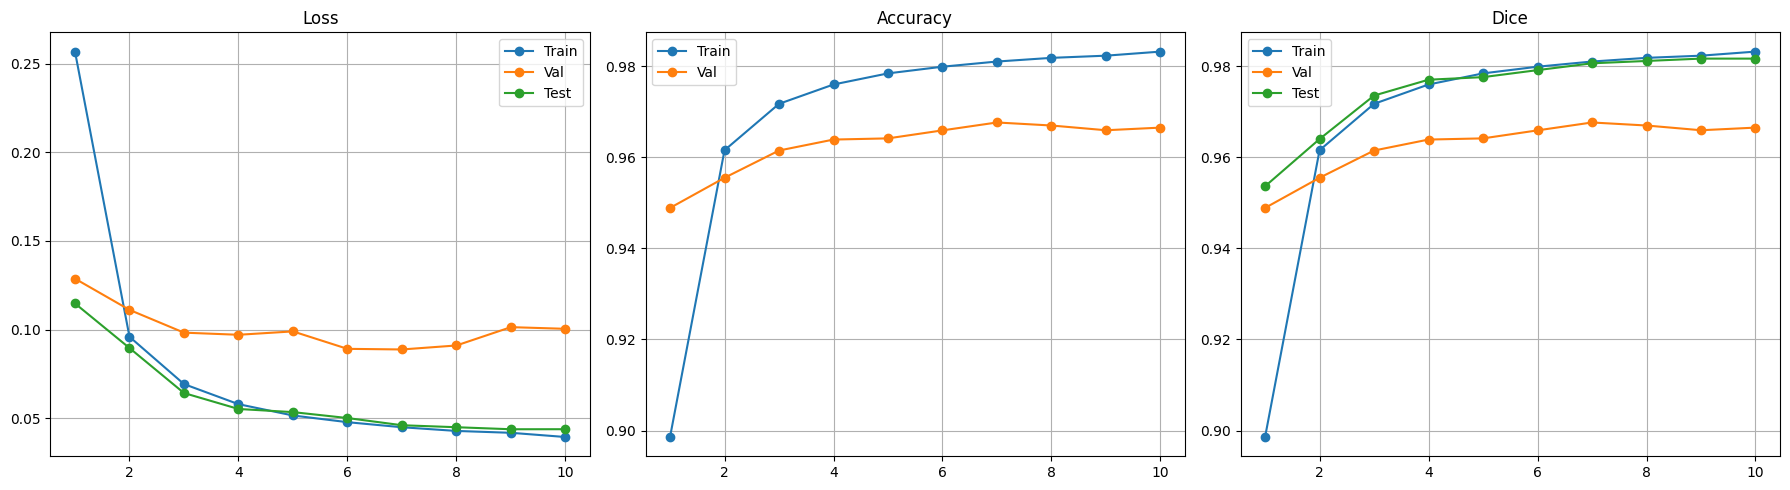

In [14]:
# ============================================
# 🔹 1. Imports
# ============================================

import os
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report

torch.backends.cudnn.benchmark = True

# ============================================
# 🔹 2. Load Data
# ============================================

BASE_PATH = r"D:\CMR-MULTI\CINE-MULTI"

PROBLEM_TYPE = "CINE"
IMAGE_TYPE = "2CH"

TRAIN_IMAGE_PATH = os.path.join(
    BASE_PATH,
    "2CH_TR",
    "image"
)

TRAIN_MASK_PATH = os.path.join(
    BASE_PATH,
    "2CH_TR",
    "anno"
)

VAL_IMAGE_PATH = os.path.join(
    BASE_PATH,
    "2CH_VAL",
    "image"
)

VAL_MASK_PATH = os.path.join(
    BASE_PATH,
    "2CH_VAL",
    "anno"
)

# ============================================
# 🔹 3. Dataset
# ============================================

class NiftiDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.samples = []

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        files = sorted(os.listdir(image_dir))

        for f in files:

            img_path = os.path.join(image_dir, f)

            img_obj = nib.load(img_path)

            depth = img_obj.shape[2]

            for i in range(depth):

                self.samples.append((f, i))

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        fname, i = self.samples[idx]

        img = nib.load(
            os.path.join(self.image_dir, fname)
        ).dataobj[:, :, i]

        mask = nib.load(
            os.path.join(self.mask_dir, fname)
        ).dataobj[:, :, i]

        img = np.array(img)
        mask = np.array(mask)

        # =====================================
        # Safe Normalization
        # =====================================

        img = img.astype(np.float32)

        if img.max() > img.min():

            img = (img - img.min()) / (img.max() - img.min())

        else:

            img = np.zeros_like(img)

        img = np.nan_to_num(img)

        # =====================================
        # Convert to Tensor
        # =====================================

        img = torch.tensor(img).unsqueeze(0).float()

        mask = torch.tensor(mask).long()

        # =====================================
        # Resize
        # =====================================

        img = F.interpolate(
            img.unsqueeze(0),
            (256,256),
            mode='bilinear'
        ).squeeze(0)

        mask = F.interpolate(
            mask.unsqueeze(0).unsqueeze(0).float(),
            (256,256),
            mode='nearest'
        ).squeeze().long()

        return img, mask

# ============================================
# 🔹 4. Split Dataset
# ============================================

train_test_dataset = NiftiDataset(
    TRAIN_IMAGE_PATH,
    TRAIN_MASK_PATH
)

val_dataset = NiftiDataset(
    VAL_IMAGE_PATH,
    VAL_MASK_PATH
)

total_size = len(train_test_dataset)

train_size = int(0.75 * total_size)

test_size = total_size - train_size

train_data, test_data = random_split(
    train_test_dataset,
    [train_size, test_size]
)

val_data = val_dataset

print(f"\nTotal TR Samples : {total_size}")
print(f"Train Samples    : {train_size}")
print(f"Test Samples     : {test_size}")
print(f"Val Samples      : {len(val_dataset)}")

# ============================================
# 🔹 5. DataLoader
# ============================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

PIN_MEMORY = True if device.type == "cuda" else False

train_loader = DataLoader(
    train_data,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_data,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_data,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

# ============================================
# 🔹 6. Model
# ============================================

NUM_CLASSES = 3

class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()

        )

    def forward(self, x):

        return self.net(x)

class UNet(nn.Module):

    def __init__(self, n_classes):

        super().__init__()

        self.d1 = DoubleConv(1,64)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(64,128)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = DoubleConv(128,256)
        self.p3 = nn.MaxPool2d(2)

        self.bn = DoubleConv(256,512)

        self.u3 = nn.ConvTranspose2d(512,256,2,2)
        self.c3 = DoubleConv(512,256)

        self.u2 = nn.ConvTranspose2d(256,128,2,2)
        self.c2 = DoubleConv(256,128)

        self.u1 = nn.ConvTranspose2d(128,64,2,2)
        self.c1 = DoubleConv(128,64)

        self.out = nn.Conv2d(64,n_classes,1)

    def forward(self,x):

        x1 = self.d1(x)

        x2 = self.d2(self.p1(x1))

        x3 = self.d3(self.p2(x2))

        x4 = self.bn(self.p3(x3))

        x = self.c3(torch.cat([self.u3(x4),x3],1))

        x = self.c2(torch.cat([self.u2(x),x2],1))

        x = self.c1(torch.cat([self.u1(x),x1],1))

        return self.out(x)

# ============================================
# 🔹 7. Metrics
# ============================================

def dice(pred, target):

    pred = torch.argmax(pred, dim=1)

    return (pred == target).float().mean()

def acc(pred, target):

    pred = torch.argmax(pred, dim=1)

    return (pred == target).float().mean()

# ============================================
# 🔹 8. Setup
# ============================================

print("\nDevice:", device)

model = UNet(NUM_CLASSES).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

criterion = nn.CrossEntropyLoss()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)

# ============================================
# 🔹 9. Checkpoint + History
# ============================================

checkpoint_path = r"D:\CMR-MULTI\CMR-MULTI\unet_2CH_checkpoint_v22.pth"

history_path = r"D:\CMR-MULTI\CMR-MULTI\training_history_2CH.csv"

start_epoch = 0

# Lists
train_loss_l = []
val_loss_l = []
test_loss_l = []

train_dice_l = []
val_dice_l = []
test_dice_l = []

train_acc_l = []
val_acc_l = []


# ============================================
# 🔹 Load Checkpoint
# ============================================

if os.path.exists(checkpoint_path):

    print("\n🔄 Loading checkpoint...")

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    try:

        model.load_state_dict(checkpoint["model"])

        optimizer.load_state_dict(
            checkpoint["optimizer"]
        )

        start_epoch = checkpoint["epoch"] + 1

        print(f"✅ Resume from epoch {start_epoch}")

    except:

        print("⚠️ Checkpoint incompatible")
        print("🚀 Starting New Training")

else:

    print("\n🚀 New Training")

# ============================================
# 🔹 Load History
# ============================================

if os.path.exists(history_path):

    history_df = pd.read_csv(history_path)

    train_loss_l = history_df["Train Loss"].tolist()
    val_loss_l = history_df["Val Loss"].tolist()
    test_loss_l = history_df["Test Loss"].tolist()

    train_dice_l = history_df["Train Dice"].tolist()
    val_dice_l = history_df["Val Dice"].tolist()
    test_dice_l = history_df["Test Dice"].tolist()

    train_acc_l = history_df["Train Acc"].tolist()
    val_acc_l = history_df["Val Acc"].tolist()
   

    print("📂 Previous history loaded")

else:

    print("🆕 New history created")

# ============================================
# 🔹 10. Training
# ============================================

epochs = 10

for ep in range(start_epoch, epochs):

    # =====================================
    # Train
    # =====================================

    model.train()

    tl, td, ta = 0,0,0

    for x,y in train_loader:

        x = x.to(device)
        y = y.to(device)

        with torch.amp.autocast(
            "cuda",
            enabled=(device.type == "cuda")
        ):

            out = model(x)

            loss = criterion(out,y)

        # Skip NaN
        if torch.isnan(loss):

            print("⚠️ NaN Loss detected")

            continue

        optimizer.zero_grad()

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        tl += loss.item()

        td += dice(out,y).item()

        ta += acc(out,y).item()

    tl /= len(train_loader)
    td /= len(train_loader)
    ta /= len(train_loader)

    # =====================================
    # Validation
    # =====================================

    model.eval()

    vl, vd, va = 0,0,0

    with torch.no_grad():

        for x,y in val_loader:

            x = x.to(device)
            y = y.to(device)

            out = model(x)

            loss = criterion(out,y)

            vl += loss.item()

            vd += dice(out,y).item()

            va += acc(out,y).item()

    vl /= len(val_loader)
    vd /= len(val_loader)
    va /= len(val_loader)

    # =====================================
    # Test
    # =====================================

    tloss, tdice = 0,0

    with torch.no_grad():

        for x,y in test_loader:

            x = x.to(device)
            y = y.to(device)

            out = model(x)

            loss = criterion(out,y)

            tloss += loss.item()

            tdice += dice(out,y).item()

            

    tloss /= len(test_loader)
    tdice /= len(test_loader)
    

    # =====================================
    # Save Metrics
    # =====================================

    train_loss_l.append(tl)
    val_loss_l.append(vl)
    test_loss_l.append(tloss)

    train_dice_l.append(td)
    val_dice_l.append(vd)
    test_dice_l.append(tdice)

    train_acc_l.append(ta)
    val_acc_l.append(va)
    

    # =====================================
    # Save History CSV
    # =====================================

    history_df = pd.DataFrame({

        "Epoch": range(1, len(train_loss_l)+1),

        "Train Loss": train_loss_l,
        "Val Loss": val_loss_l,
        "Test Loss": test_loss_l,

        "Train Dice": train_dice_l,
        "Val Dice": val_dice_l,
        "Test Dice": test_dice_l,

        "Train Acc": train_acc_l,
        "Val Acc": val_acc_l,
        

    })

    history_df.to_csv(
        history_path,
        index=False
    )

    # =====================================
    # Print Results
    # =====================================

    print(f"\nEpoch {ep+1}")

    print("-"*45)

    print(f"{'Metric':<12} | {'Train':<8} | {'Val':<8} | {'Test':<8}")

    print("-"*45)

    print(f"{'Loss':<12} | {tl:.4f} | {vl:.4f} | {tloss:.4f}")

    print(f"{'Dice':<12} | {td:.4f} | {vd:.4f} | {tdice:.4f}")

    print(f"{'Accuracy':<12} | {ta:.4f} | {va:.4f} | {'--'}")

    # =====================================
    # Save Checkpoint
    # =====================================

    torch.save({

        "epoch": ep,

        "model": model.state_dict(),

        "optimizer": optimizer.state_dict()

    }, checkpoint_path)

    print("💾 Checkpoint Saved")

    # =====================================
    # Memory Cleanup
    # =====================================

    torch.cuda.empty_cache()

    gc.collect()

# ============================================
# 🔹 11. Lightweight Classification Report
# ============================================

from sklearn.metrics import classification_report

all_preds = []

all_targets = []

model.eval()

# Use small sample only to avoid MemoryError
MAX_BATCHES = 20

with torch.no_grad():

    for i, (x,y) in enumerate(test_loader):

        # Stop after limited batches
        if i >= MAX_BATCHES:
            break

        x = x.to(device)

        out = model(x)

        preds = torch.argmax(out, dim=1)

        # Reduce memory usage
        all_preds.extend(

            preds.cpu().view(-1).numpy()[::50]

        )

        all_targets.extend(

            y.view(-1).numpy()[::50]

        )

# ============================================
# 🔹 Print Report
# ============================================

print("\n📊 Classification Report:\n")

print(

    classification_report(

        all_targets,

        all_preds,

        digits=2

    )

)

# ============================================
# 🔹 Memory Cleanup
# ============================================

del all_preds
del all_targets

gc.collect()

torch.cuda.empty_cache()

# ============================================
# 🔹 12. Plot Results
# ============================================

ep_range = range(1, len(train_loss_l)+1)

plt.figure(figsize=(18,5))

# Loss
plt.subplot(1,3,1)

plt.plot(ep_range, train_loss_l, 'o-', label='Train')
plt.plot(ep_range, val_loss_l, 'o-', label='Val')
plt.plot(ep_range, test_loss_l, 'o-', label='Test')

plt.title("Loss")

plt.legend()

plt.grid()

# Accuracy
plt.subplot(1,3,2)

plt.plot(ep_range, train_acc_l, 'o-', label='Train')
plt.plot(ep_range, val_acc_l, 'o-', label='Val')


plt.title("Accuracy")

plt.legend()

plt.grid()

# Dice
plt.subplot(1,3,3)

plt.plot(ep_range, train_dice_l, 'o-', label='Train')
plt.plot(ep_range, val_dice_l, 'o-', label='Val')
plt.plot(ep_range, test_dice_l, 'o-', label='Test')

plt.title("Dice")

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

In [15]:
# ============================================
# Final Test Accuracy
# ============================================

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        outputs = model(x)

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y).sum().item()

        total += y.numel()

test_accuracy = correct / total

print(f"\nFinal Test Accuracy = {test_accuracy:.4f}")



Final Test Accuracy = 0.9817


# 🎨 Professional Medical Visualization
# 2CH / 3 Classes

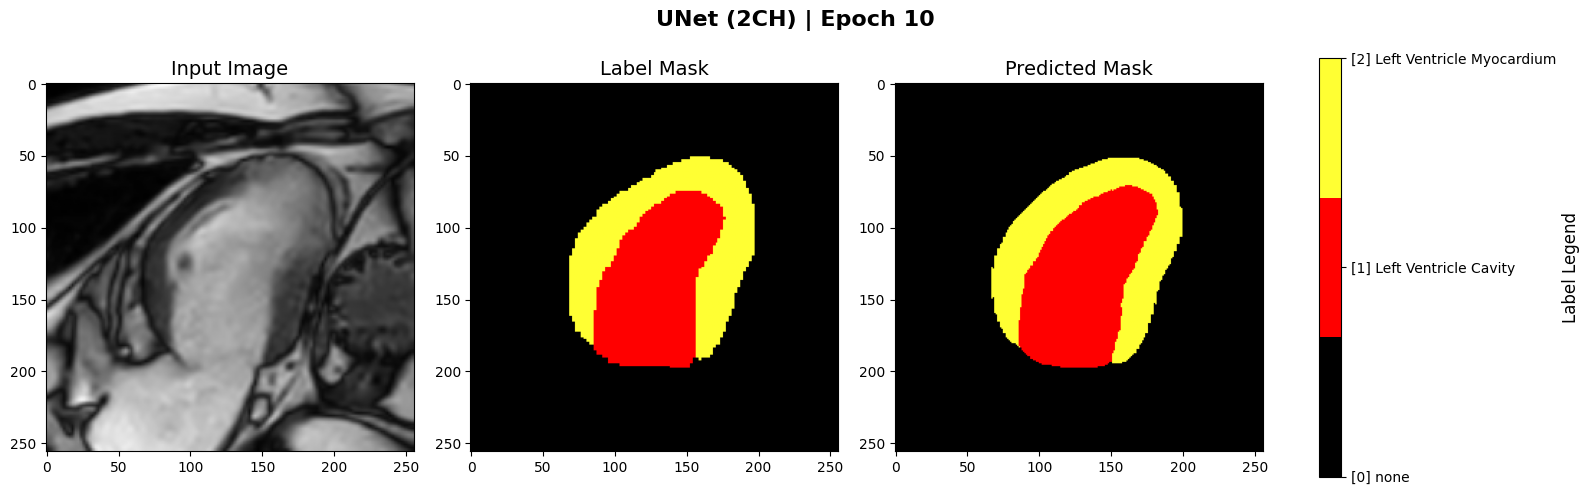

In [16]:
# ============================================
# 🎨 Professional Medical Visualization
# 2CH / 3 Classes
# ============================================

import random
import torch
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

# ============================================
# 📌 Model Name
# ============================================

MODEL_NAME = "UNet (2CH)"

# ============================================
# 📌 Load Checkpoint Info
# ============================================

checkpoint = torch.load(

    checkpoint_path,

    map_location=device,

    weights_only=False

)

epoch_num = checkpoint["epoch"] + 1

# ============================================
# 📌 Class Labels
# ============================================

CLASS_NAMES = [

    "[0] none",

    "[1] Left Ventricle Cavity",

    "[2] Left Ventricle Myocardium"

]

# ============================================
# 🎨 Colors
# ============================================

COLORS = [

    (0, 0, 0),        # Background → Black

    (1, 0, 0),        # LV Cavity → Red

    (1, 1, 0.2)       # LV Myocardium → Yellow

]

CMAP = ListedColormap(COLORS)

# ============================================
# 🧠 Prediction
# ============================================

model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

    preds = torch.argmax(outputs, dim=1)

images = images.cpu()

masks = masks.cpu()

preds = preds.cpu()

# ============================================
# 🎲 Random Sample
# ============================================

idx = random.randint(
    0,
    images.shape[0] - 1
)

img = images[idx].squeeze().numpy()

gt = masks[idx].numpy()

pr = preds[idx].numpy()

# ============================================
# 📊 Plot Figure
# ============================================

fig, axes = plt.subplots(

    1,
    4,

    figsize=(16,5),

    gridspec_kw={
        'width_ratios': [1,1,1,0.06]
    }

)

# ============================================
# 🖼️ Input Image
# ============================================

axes[0].imshow(
    img,
    cmap='gray'
)

axes[0].set_title(
    "Input Image",
    fontsize=14
)

axes[0].axis('on')

# ============================================
# 🎯 Ground Truth
# ============================================

axes[1].imshow(

    gt,

    cmap=CMAP,

    vmin=0,

    vmax=2

)

axes[1].set_title(

    "Label Mask",

    fontsize=14

)

axes[1].axis('on')

# ============================================
# 🤖 Prediction
# ============================================

axes[2].imshow(

    pr,

    cmap=CMAP,

    vmin=0,

    vmax=2

)

axes[2].set_title(

    "Predicted Mask",

    fontsize=14

)

axes[2].axis('on')

# ============================================
# 🎨 Colorbar
# ============================================

norm = plt.Normalize(
    vmin=0,
    vmax=2
)

cbar = plt.colorbar(

    plt.cm.ScalarMappable(

        norm=norm,

        cmap=CMAP

    ),

    cax=axes[3]

)

cbar.set_ticks(
    np.arange(len(CLASS_NAMES))
)

cbar.set_ticklabels(CLASS_NAMES)

cbar.ax.set_ylabel(

    "Label Legend",

    rotation=90,

    fontsize=12

)

# ============================================
# 🏷️ Main Title
# ============================================

plt.suptitle(

    f"{MODEL_NAME} | Epoch {epoch_num}",

    fontsize=16,

    fontweight='bold'

)

plt.tight_layout()

plt.show()